# Cholesky Decomposition
> **Numerical Methods for Engineering** | Module 02 - Linear Systems | `03_Cholesky.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/02-Linear-Systems/03_Cholesky.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- Define a **symmetric positive definite (SPD)** matrix and verify the three equivalent conditions.
- Derive and apply the **Cholesky algorithm** to compute $A = LL^T$.
- Explain why Cholesky requires $\approx n^3/6$ operations — **half the cost** of LU decomposition.
- Detect non-positive-definiteness via a failed square root step.
- Use Cholesky to solve linear systems and the **normal equations** $A^T A\,\mathbf{x} = A^T \mathbf{b}$.
- Apply the method to SPD engineering systems, Arrhenius kinetics fitting, and MIMO channel estimation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(11,5),'font.size':12,
    'axes.grid':True,'grid.alpha':0.35,'lines.linewidth':2})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 Symmetric Positive Definite (SPD) Matrices

A matrix $A \in \mathbb{R}^{n \times n}$ is **symmetric positive definite** if:

$$A = A^T \qquad \text{and} \qquad \mathbf{x}^T A\,\mathbf{x} > 0 \quad \forall\,\mathbf{x} \neq \mathbf{0}$$

**Equivalent conditions** (any one is sufficient):
1. All **eigenvalues** of $A$ are strictly positive: $\lambda_i > 0$.
2. All **leading principal minors** are positive (Sylvester's criterion).
3. The Cholesky factorisation **exists and is unique** with positive diagonal in $L$.

**Common sources of SPD matrices in engineering:**
- Finite-element **stiffness matrices** (structural mechanics, heat transfer)
- **Gramian matrices** $A^T A$ from least-squares problems
- **Covariance matrices** in statistics and signal processing
- **Laplacian matrices** of undirected graphs

---

### 1.2 Cholesky Factorisation: $A = LL^T$

Every SPD matrix has a unique factorisation $A = LL^T$ where $L$ is lower triangular with
strictly positive diagonal entries.

Matching $A = LL^T$ column by column yields the **Cholesky–Banachiewicz recurrences**:

**Diagonal entries** (column $k$, row $k$):

$$l_{kk} = \sqrt{a_{kk} - \sum_{j=0}^{k-1} l_{kj}^2}$$

**Off-diagonal entries** (column $k$, rows $i > k$):

$$l_{ik} = \frac{1}{l_{kk}}\left(a_{ik} - \sum_{j=0}^{k-1} l_{ij}\,l_{kj}\right)$$

If the argument of any square root is $\leq 0$, the matrix is **not** positive definite —
Cholesky provides a built-in SPD check.

---

### 1.3 Operation Count: Half of LU

The total number of multiplications is:

$$\text{Cholesky:}\; \frac{n^3}{6} + \mathcal{O}(n^2) \qquad\text{vs}\qquad
\text{LU:}\; \frac{n^3}{3} + \mathcal{O}(n^2)$$

Cholesky is **exactly twice as fast** as LU for large $n$ because it exploits symmetry —
only the lower triangle is computed and stored.

---

### 1.4 Solving $A\mathbf{x} = \mathbf{b}$

With $A = LL^T$, solve in two $\mathcal{O}(n^2)$ steps:

1. **Forward substitution** — solve $L\mathbf{y} = \mathbf{b}$:
$$y_i = \frac{b_i - \displaystyle\sum_{j=0}^{i-1} l_{ij}\,y_j}{l_{ii}}$$

2. **Back substitution** — solve $L^T\mathbf{x} = \mathbf{y}$:
$$x_i = \frac{y_i - \displaystyle\sum_{j=i+1}^{n-1} l_{ji}\,x_j}{l_{ii}}$$

---

### 1.5 Normal Equations and Least Squares

Given an overdetermined system $X\boldsymbol{\beta} \approx \mathbf{y}$ (more equations than unknowns),
the **least-squares solution** minimises $\|X\boldsymbol{\beta} - \mathbf{y}\|^2$ and satisfies:

$$\underbrace{X^T X}_{\text{SPD if rank}(X)=p}\,\boldsymbol{\beta} = X^T\mathbf{y}$$

Since $X^T X$ is always SPD when $X$ has full column rank, Cholesky is the **optimal direct
solver** for normal equations.

---

### 1.6 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| **2× faster** than LU for SPD systems | **Requires SPD** — fails for indefinite or non-symmetric matrices |
| **Half the storage**: only $L$ needed | No partial pivoting needed (SPD guarantees stability) |
| Built-in SPD check (negative under sqrt) | Ill-conditioning near semi-definiteness requires regularisation |
| Numerically stable **without pivoting** | Not directly applicable to complex Hermitian matrices (needs $LDL^H$) |


In [2]:
def cholesky(A):
    # Cholesky decomposition: returns lower triangular L such that A = L @ L.T
    # Raises ValueError if A is not positive definite.
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L = np.zeros((n, n))
    for k in range(n):
        # Diagonal entry
        val = A[k, k] - np.dot(L[k, :k], L[k, :k])
        if val <= 0:
            raise ValueError(
                f'Matrix is NOT positive definite: step k={k}, val={val:.4e}')
        L[k, k] = np.sqrt(val)
        # Off-diagonal entries in column k
        for i in range(k + 1, n):
            L[i, k] = (A[i, k] - np.dot(L[i, :k], L[k, :k])) / L[k, k]
    return L


def chol_solve(L, b):
    # Solve A x = b given A = L L^T.  Two O(n^2) substitutions.
    b = np.array(b, dtype=float)
    n = len(b)
    # 1. Forward substitution: L y = b
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    # 2. Back substitution: L^T x = y
    x = np.zeros(n)
    LT = L.T
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - LT[i, i+1:] @ x[i+1:]) / LT[i, i]
    return x


def is_spd(A, tol=1e-12):
    # Check SPD via eigenvalues (exact but O(n^3)) and symmetry.
    A = np.array(A, dtype=float)
    sym_err = np.max(np.abs(A - A.T))
    eigs    = np.linalg.eigvalsh(A)
    return sym_err < tol and np.min(eigs) > 0, sym_err, np.min(eigs)

print('cholesky(), chol_solve(), is_spd() defined.')

cholesky(), chol_solve(), is_spd() defined.


---
## 2. Examples

### 2.1 General Mathematical Example — SPD System and Structural Stiffness Matrix

The **finite-element stiffness matrix** for a 1D bar element with $n=5$ nodes and homogeneous
Dirichlet conditions is tridiagonal and SPD:

$$K = \frac{EA}{L_e}\begin{bmatrix}
 2 & -1 &    &    \\
-1 &  2 & -1 &    \\
   & \ddots & \ddots & \ddots \\
   &    & -1 &  2
\end{bmatrix}$$

where $E = 200$ GPa (steel), $A = 10^{-4}$ m$^2$, $L_e = 0.2$ m.

We verify $A = LL^T$ entry by entry, compare eigenvalues of $K$ vs diagonal of $L$,
and demonstrate that a perturbed non-SPD matrix is correctly rejected.


K is SPD: True  |  symmetry error: 0.00e+00  |  min eigenvalue: 2.6795e+07

Max |K - L L^T| = 2.98e-08

L (lower triangular Cholesky factor, rounded):
[[ 0.0001  0.      0.      0.      0.    ]
 [-0.0001  0.0001  0.      0.      0.    ]
 [ 0.     -0.0001  0.0001  0.      0.    ]
 [ 0.      0.     -0.0001  0.0001  0.    ]
 [ 0.      0.      0.     -0.0001  0.0001]]   [x EA/Le]

Nodal displacements u (m):
  u[1] = 25.0000 um
  u[2] = 40.0000 um
  u[3] = 45.0000 um
  u[4] = 40.0000 um
  u[5] = 25.0000 um
Residual ||K u - f|| = 6.82e-13

Attempting Cholesky on a non-SPD matrix...
  Correctly rejected: Matrix is NOT positive definite: step k=2, val=-6.6767e+07


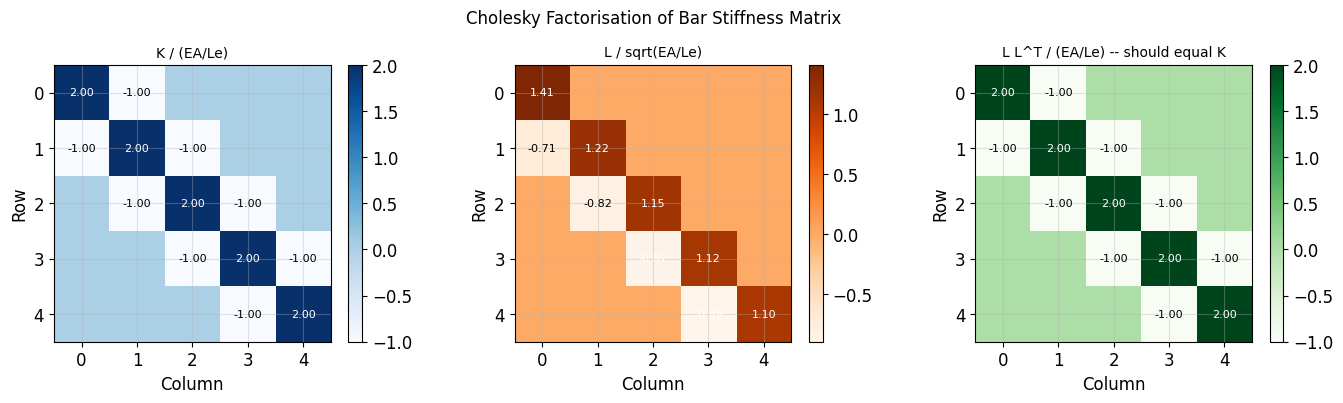

In [3]:
E  = 200e9    # Pa  (Young's modulus, steel)
Ac = 1e-4     # m^2 (cross-sectional area)
Le = 0.2      # m   (element length)
n_nodes = 5   # interior nodes (clamped-clamped bar with 5 free dofs)

# Stiffness matrix K
c = E * Ac / Le
K_bar = c * (2 * np.eye(n_nodes)
             - np.diag(np.ones(n_nodes-1), 1)
             - np.diag(np.ones(n_nodes-1), -1))

spd_ok, sym_err, min_eig = is_spd(K_bar)
print(f'K is SPD: {spd_ok}  |  symmetry error: {sym_err:.2e}  |  min eigenvalue: {min_eig:.4e}')
print()

# Cholesky factorisation
L_bar = cholesky(K_bar)
err_fact = np.max(np.abs(K_bar - L_bar @ L_bar.T))
print(f'Max |K - L L^T| = {err_fact:.2e}')
print()
print('L (lower triangular Cholesky factor, rounded):')
print(np.round(L_bar / c, 4), '  [x EA/Le]')
print()

# Solve K u = f  (distributed load f = 1000 N on each node)
f_load = np.full(n_nodes, 1000.0)  # N
u_sol  = chol_solve(L_bar, f_load)
resid  = np.max(np.abs(K_bar @ u_sol - f_load))
print('Nodal displacements u (m):')
for i, ui in enumerate(u_sol):
    print(f'  u[{i+1}] = {ui*1e6:.4f} um')
print(f'Residual ||K u - f|| = {resid:.2e}')
print()

# Demo: non-SPD matrix correctly rejected
K_bad = K_bar.copy()
K_bad[2, 2] = -1e5   # make one diagonal entry negative
print('Attempting Cholesky on a non-SPD matrix...')
try:
    cholesky(K_bad)
except ValueError as e:
    print(f'  Correctly rejected: {e}')

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, mat, title, cmap in zip(axes,
        [K_bar/c, L_bar/np.sqrt(c), (L_bar @ L_bar.T)/c],
        ['K / (EA/Le)', 'L / sqrt(EA/Le)', 'L L^T / (EA/Le) -- should equal K'],
        ['Blues', 'Oranges', 'Greens']):
    im = ax.imshow(mat, cmap=cmap, aspect='equal')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(n_nodes):
        for j in range(n_nodes):
            if abs(mat[i,j]) > 1e-10:
                ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                        fontsize=8,
                        color='white' if abs(mat[i,j]) > 0.6*np.max(np.abs(mat)) else 'black')

plt.suptitle('Cholesky Factorisation of Bar Stiffness Matrix', fontsize=12)
plt.tight_layout()
plt.show()

### 2.2 Chemistry Application — Arrhenius Kinetics Fitting via Normal Equations

**Background:** The rate constant of most chemical reactions follows the **Arrhenius equation**:

$$k(T) = A_0\,\exp\!\left(-\frac{E_a}{R\,T}\right)$$

Taking the natural logarithm linearises the relationship:

$$\underbrace{\ln k}_y = \underbrace{\ln A_0}_{c_0} - \underbrace{\frac{E_a}{R}}_{c_1}\cdot\underbrace{\frac{1}{T}}_x$$

With $m$ experimental measurements $\{(T_i, k_i)\}$, the **least-squares fit** minimises
$\sum_i (\ln k_i - c_0 - c_1/T_i)^2$, leading to the normal equations:

$$\underbrace{X^T X}_{\text{SPD, } 2\times 2}\begin{bmatrix}c_0\\c_1\end{bmatrix} = X^T \mathbf{y}$$

where $X_{i,:} = [1,\; 1/T_i]$. We apply Cholesky to this $2\times 2$ SPD system and recover
$A_0 = e^{c_0}$ and $E_a = -c_1 R$.

**Case study:** catalytic decomposition of H$_2$O$_2$ (iodide catalyst, aqueous solution).


Arrhenius data (H2O2 decomposition):
   T (K)      k (s^-1)         ln(k)    1/T (K^-1)
--------------------------------------------------
   283.0    8.3000e-04       -7.0941      0.003534
   293.0    1.8500e-03       -6.2926      0.003413
   303.0    3.9000e-03       -5.5468      0.003300
   313.0    7.9000e-03       -4.8409      0.003195
   323.0    1.5500e-02       -4.1669      0.003096
   333.0    2.9800e-02       -3.5132      0.003003
   343.0    5.5500e-02       -2.8914      0.002915

Normal equations matrix X^T X:
[[7.0000e+00 2.2456e-02]
 [2.2456e-02 7.2000e-05]]
SPD check: True  |  min eigenvalue = 2.9686e-07

Arrhenius parameters (Cholesky least-squares):
  ln(A0) = c0 = 16.8606
  A0     = 2.1012e+07 s^-1
  -Ea/R  = c1 = -6785.22 K
  Ea     = 56.41 kJ/mol

  R^2 = 0.999813  (1.0 = perfect fit)


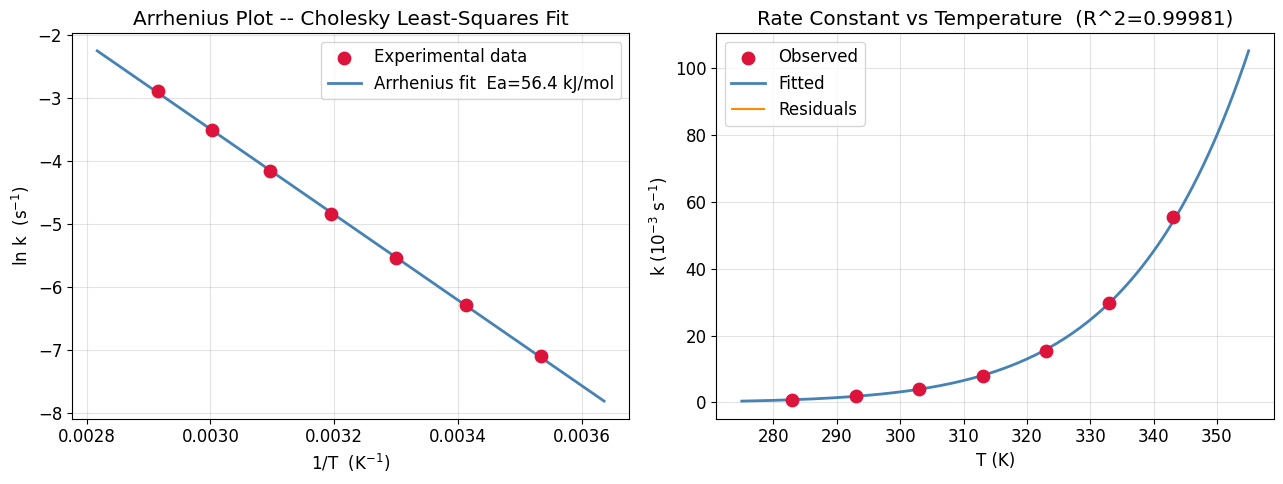

In [4]:
# Experimental data: rate constants at different temperatures
T_data  = np.array([283.0, 293.0, 303.0, 313.0, 323.0, 333.0, 343.0])  # K
k_obs   = np.array([8.3e-4, 1.85e-3, 3.90e-3, 7.90e-3,
                    1.55e-2, 2.98e-2, 5.55e-2])  # s^-1 (with realistic noise)
R_gas   = 8.314   # J/(mol.K)

print('Arrhenius data (H2O2 decomposition):')
print('{:>8}  {:>12}  {:>12}  {:>12}'.format('T (K)', 'k (s^-1)', 'ln(k)', '1/T (K^-1)'))
print('-'*50)
for Ti, ki in zip(T_data, k_obs):
    print('{:>8.1f}  {:>12.4e}  {:>12.4f}  {:>12.6f}'.format(Ti, ki, np.log(ki), 1/Ti))
print()

# Build design matrix X and response y
X_des = np.column_stack([np.ones(len(T_data)), 1.0/T_data])
y_vec = np.log(k_obs)

# Normal equations: (X^T X) c = X^T y
A_norm = X_des.T @ X_des
b_norm = X_des.T @ y_vec

print('Normal equations matrix X^T X:')
print(np.round(A_norm, 6))
spd_ok, _, min_eig = is_spd(A_norm)
print(f'SPD check: {spd_ok}  |  min eigenvalue = {min_eig:.4e}')
print()

# Solve with Cholesky
L_norm = cholesky(A_norm)
c_fit  = chol_solve(L_norm, b_norm)
c0, c1 = c_fit

A0_fit = np.exp(c0)            # pre-exponential factor
Ea_fit = -c1 * R_gas / 1000.0  # activation energy in kJ/mol

print('Arrhenius parameters (Cholesky least-squares):')
print(f'  ln(A0) = c0 = {c0:.4f}')
print(f'  A0     = {A0_fit:.4e} s^-1')
print(f'  -Ea/R  = c1 = {c1:.2f} K')
print(f'  Ea     = {Ea_fit:.2f} kJ/mol')
print()

# Fit quality: R^2
y_hat = X_des @ c_fit
ss_res = np.sum((y_vec - y_hat)**2)
ss_tot = np.sum((y_vec - np.mean(y_vec))**2)
r2 = 1 - ss_res / ss_tot
print(f'  R^2 = {r2:.6f}  (1.0 = perfect fit)')

# Visualisation
T_fine = np.linspace(275, 355, 200)
k_fit  = A0_fit * np.exp(-Ea_fit*1000 / (R_gas * T_fine))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(1/T_data, np.log(k_obs), s=80, color='crimson', zorder=5,
           label='Experimental data')
ax.plot(1/T_fine, np.log(k_fit), color='steelblue', lw=2,
        label=f'Arrhenius fit  Ea={Ea_fit:.1f} kJ/mol')
ax.set(xlabel='1/T  (K$^{-1}$)', ylabel='ln k  (s$^{-1}$)',
       title='Arrhenius Plot -- Cholesky Least-Squares Fit')
ax.legend()

ax = axes[1]
ax.scatter(T_data, k_obs*1000, s=80, color='crimson', zorder=5, label='Observed')
ax.plot(T_fine, k_fit*1000, color='steelblue', lw=2, label='Fitted')
residuals = k_obs - A0_fit * np.exp(-Ea_fit*1000/(R_gas*T_data))
ax.vlines(T_data, k_obs*1000,
          (k_obs+residuals)*1000,
          color='darkorange', lw=1.5, label='Residuals')
ax.set(xlabel='T (K)', ylabel='k (10$^{-3}$ s$^{-1}$)',
       title=f'Rate Constant vs Temperature  (R^2={r2:.5f})')
ax.legend()

plt.tight_layout()
plt.show()

### 2.3 Telecommunications Application — MIMO Least-Squares Channel Estimation

**Background:** In a MIMO (Multiple-Input Multiple-Output) wireless system, the received
signal vector $\mathbf{y} \in \mathbb{C}^{n_r}$ is related to the transmitted symbol
vector $\mathbf{s} \in \mathbb{C}^{n_t}$ by:

$$\mathbf{y} = H\,\mathbf{s} + \boldsymbol{\eta}$$

where $H \in \mathbb{C}^{n_r \times n_t}$ is the **channel matrix** and $\boldsymbol{\eta}$
is additive white Gaussian noise with variance $\sigma^2 I$.

When $n_r \geq n_t$ and $H$ is known (**coherent detection**), the **least-squares estimator**
minimises $\|\mathbf{y} - H\mathbf{s}\|^2$:

$$\hat{\mathbf{s}} = (H^H H)^{-1} H^H \mathbf{y} \qquad \Longleftrightarrow \qquad
\underbrace{H^H H}_{\text{SPD if rank}(H)=n_t}\,\hat{\mathbf{s}} = H^H \mathbf{y}$$

We solve the normal equations using Cholesky and study the **estimation error vs SNR**.
System parameters: $n_t = 3$ transmit, $n_r = 6$ receive antennas.


Gram matrix G = H^H H  |  SPD: True  |  min eigenvalue = 1.4873
Condition number of G: 12.89

Cholesky factorisation: max|G - L L^T| = 1.78e-15



BER vs SNR (Cholesky LS vs Matched Filter):
 SNR(dB)        BER (LS)        BER (MF)
----------------------------------------
      -4      1.2734e-01      1.3659e-01
      -2      7.7756e-02      1.1897e-01
       0      3.9933e-02      1.0720e-01
       2      1.5778e-02      9.9656e-02
       4      4.1444e-03      9.3689e-02
       6      7.1111e-04      8.7889e-02
       8      2.2222e-05      7.9522e-02
      10      0.0000e+00      7.2422e-02
      12      0.0000e+00      6.6389e-02
      14      0.0000e+00      6.2911e-02
      16      0.0000e+00      6.2178e-02
      18      0.0000e+00      6.3033e-02
      20      0.0000e+00      6.7144e-02


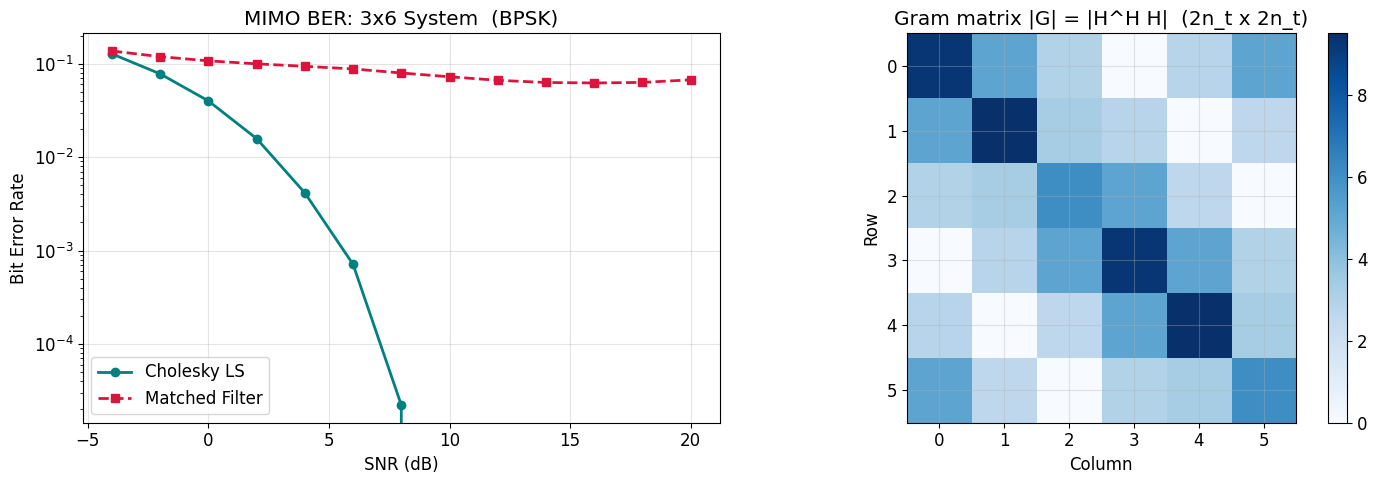

In [5]:
rng    = np.random.default_rng(42)
n_t    = 3      # transmit antennas
n_r    = 6      # receive antennas
n_sym  = 500    # number of BPSK symbols per trial

# Generate random Rayleigh flat-fading channel (fixed for this simulation)
H_re = rng.standard_normal((n_r, n_t))
H_im = rng.standard_normal((n_r, n_t))
# Work with 2n_r x 2n_t real equivalent: [Re(H) -Im(H); Im(H) Re(H)]
H_block = np.block([[H_re, -H_im], [H_im, H_re]])  # (2n_r) x (2n_t)

# Gram matrix (should be SPD)
G_mimo = H_block.T @ H_block   # (2n_t) x (2n_t)
spd_ok, _, min_eig = is_spd(G_mimo)
print(f'Gram matrix G = H^H H  |  SPD: {spd_ok}  |  min eigenvalue = {min_eig:.4f}')
print(f'Condition number of G: {np.linalg.cond(G_mimo):.2f}')
print()

# Cholesky factorisation of G (done once per channel realisation)
L_mimo = cholesky(G_mimo)
print(f'Cholesky factorisation: max|G - L L^T| = {np.max(np.abs(G_mimo - L_mimo @ L_mimo.T)):.2e}')
print()

# Monte Carlo: BER vs SNR
snr_dB  = np.arange(-4, 22, 2)
ber_ls  = []
ber_mf  = []   # matched filter (H^H y) for comparison

for snr in snr_dB:
    sigma2 = 10**(-snr/10.0)   # noise variance per real dimension
    n_err_ls = 0
    n_err_mf = 0
    for _ in range(60):         # 60 blocks of n_sym symbols
        # BPSK symbols: +1 / -1
        s_tx_re = rng.choice([-1, 1], size=(n_t, n_sym)).astype(float)
        s_tx_im = np.zeros((n_t, n_sym))
        s_block = np.vstack([s_tx_re, s_tx_im])  # (2n_t) x n_sym

        # Received signal + noise
        noise   = np.sqrt(sigma2) * rng.standard_normal((2*n_r, n_sym))
        y_rx    = H_block @ s_block + noise

        # LS estimate: solve G s_hat = H^T y  (Cholesky, O(n^2) per column)
        rhs_ls  = H_block.T @ y_rx  # (2n_t) x n_sym
        s_hat   = np.zeros_like(rhs_ls)
        for col in range(n_sym):
            s_hat[:, col] = chol_solve(L_mimo, rhs_ls[:, col])

        # Decision (BPSK): sign of real component (first n_t rows)
        s_dec_ls = np.sign(s_hat[:n_t, :])
        s_dec_mf = np.sign((H_block.T @ y_rx)[:n_t, :])  # matched filter

        n_err_ls += np.sum(s_dec_ls != s_tx_re)
        n_err_mf += np.sum(s_dec_mf != s_tx_re)

    total = 60 * n_t * n_sym
    ber_ls.append(n_err_ls / total)
    ber_mf.append(n_err_mf / total)

print('BER vs SNR (Cholesky LS vs Matched Filter):')
print('{:>8}  {:>14}  {:>14}'.format('SNR(dB)', 'BER (LS)', 'BER (MF)'))
print('-'*40)
for snr, bl, bm in zip(snr_dB, ber_ls, ber_mf):
    print('{:>8}  {:>14.4e}  {:>14.4e}'.format(snr, bl, bm))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(snr_dB, ber_ls, 'o-', color='teal',      ms=6, lw=2, label='Cholesky LS')
ax.semilogy(snr_dB, ber_mf, 's--', color='crimson',  ms=6, lw=2, label='Matched Filter')
ax.set(xlabel='SNR (dB)', ylabel='Bit Error Rate',
       title=f'MIMO BER: {n_t}x{n_r} System  (BPSK)')
ax.legend()

ax = axes[1]
# Gram matrix heatmap
im = ax.imshow(np.abs(G_mimo), cmap='Blues', aspect='equal')
ax.set_title('Gram matrix |G| = |H^H H|  (2n_t x 2n_t)')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

---
## 3. Efficiency: Cholesky vs LU Decomposition

For an $n \times n$ SPD system, the theoretical operation counts are:

| Method | Multiplications | Relative cost |
|--------|----------------|---------------|
| LU (Doolittle) | $n^3/3$ | $1\times$ |
| **Cholesky** | $n^3/6$ | **$0.5\times$** |
| Cholesky + 1 solve | $n^3/6 + n^2$ | $\approx 0.5\times$ for large $n$ |

We verify this empirically by timing both methods on symmetric positive definite matrices
of increasing size. Since Cholesky avoids computing the upper triangle, it is not only
faster but also uses less memory (only $n(n+1)/2$ vs $n^2$ entries).


     n    Cholesky (s)          LU (s)      Speed-up
----------------------------------------------------
    20      2.8608e-04      1.9983e-04          0.70x
    40      5.0771e-04      7.2592e-04          1.43x
    60      1.1210e-03      1.8251e-03          1.63x
    80      2.0666e-03      2.9778e-03          1.44x
   100      3.1329e-03      4.6400e-03          1.48x
   120      4.9023e-03      6.7923e-03          1.39x


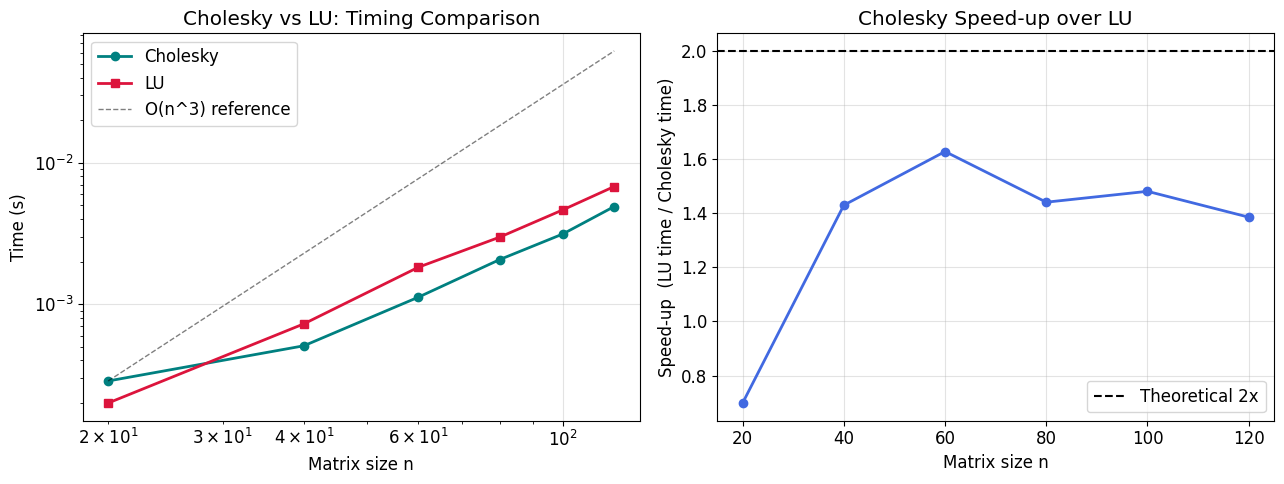

In [6]:
import time

# Import lu_decompose from notebook 02 (inline copy)
def lu_decompose_local(A):
    A = np.array(A, dtype=float); n = A.shape[0]
    L = np.eye(n); U = A.copy(); P = np.eye(n)
    for k in range(n-1):
        p = k + int(np.argmax(np.abs(U[k:, k])))
        if p != k:
            U[[k,p]] = U[[p,k]]; P[[k,p]] = P[[p,k]]
            if k > 0: L[[k,p], :k] = L[[p,k], :k]
        for i in range(k+1, n):
            L[i,k] = U[i,k]/U[k,k]; U[i,k:] -= L[i,k]*U[k,k:]
    return L, U, P

sizes = [20, 40, 60, 80, 100, 120]
t_chol, t_lu = [], []
rng2 = np.random.default_rng(99)

for n in sizes:
    # Generate SPD matrix: A = B^T B + n*I
    B = rng2.standard_normal((n, n))
    A_spd = B.T @ B + n * np.eye(n)

    t0 = time.perf_counter()
    cholesky(A_spd)
    t_chol.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    lu_decompose_local(A_spd)
    t_lu.append(time.perf_counter() - t0)

print('{:>6}  {:>14}  {:>14}  {:>12}'.format('n', 'Cholesky (s)', 'LU (s)', 'Speed-up'))
print('-'*52)
for n, tc, tl in zip(sizes, t_chol, t_lu):
    print('{:>6}  {:>14.4e}  {:>14.4e}  {:>12.2f}x'.format(n, tc, tl, tl/tc))

# Visualisation: timing + speed-up
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(sizes, t_chol, 'o-', color='teal',    ms=6, lw=2, label='Cholesky')
ax.loglog(sizes, t_lu,   's-', color='crimson', ms=6, lw=2, label='LU')
n_arr = np.array(sizes, dtype=float)
ax.loglog(n_arr, t_chol[0]*(n_arr/sizes[0])**3, 'k--', lw=1,
          alpha=0.5, label='O(n^3) reference')
ax.set(xlabel='Matrix size n', ylabel='Time (s)',
       title='Cholesky vs LU: Timing Comparison')
ax.legend()

ax = axes[1]
speedup = [tl/tc for tc, tl in zip(t_chol, t_lu)]
ax.plot(sizes, speedup, 'o-', color='royalblue', ms=6, lw=2)
ax.axhline(2.0, color='k', ls='--', lw=1.5, label='Theoretical 2x')
ax.set(xlabel='Matrix size n', ylabel='Speed-up  (LU time / Cholesky time)',
       title='Cholesky Speed-up over LU')
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Student Exercises

---

**Exercise 1 — SPD verification toolkit**
Write a function `make_spd_report(A)` that checks: (a) symmetry error $\|A - A^T\|_\infty$,
(b) minimum eigenvalue via `np.linalg.eigvalsh`, (c) success/failure of the Cholesky
attempt. Test it on four matrices: a random SPD, a symmetric indefinite (some negative
eigenvalues), a non-symmetric matrix, and the Hilbert matrix $H_{ij} = 1/(i+j-1)$ for $n=6$.

---

**Exercise 2 — $LDL^T$ decomposition**
The **$LDL^T$ factorisation** writes $A = L D L^T$ with unit lower triangular $L$ and
diagonal $D$. It avoids square roots (useful in floating-point arithmetic), with recurrences:

$$d_k = a_{kk} - \sum_{j=0}^{k-1} l_{kj}^2 d_j, \qquad
l_{ik} = \frac{1}{d_k}\left(a_{ik} - \sum_{j=0}^{k-1} l_{ij} l_{kj} d_j\right)$$

Implement `ldlt_decompose(A)` and verify $A = L D L^T$. Compare its solve path with standard
Cholesky.

---

**Exercise 3 — Polynomial regression via normal equations**
Fit a **cubic polynomial** $p(x) = c_0 + c_1 x + c_2 x^2 + c_3 x^3$ to noisy measurements
of a heat exchanger efficiency curve: generate data as $\eta(T) = 0.85 - 0.002(T-300)^2/10^4$
plus Gaussian noise $\sigma = 0.01$ at 20 temperature points. Build the $4 \times 4$ normal
equations matrix $X^T X$ (where $X_{ij} = T_i^j$), solve with Cholesky, and plot the fit.

---

**Exercise 4 — MIMO with channel estimation error**
Extend Example 2.3 to include **imperfect channel knowledge**: let $\hat{H} = H + \Delta H$
where $\Delta H$ has entries $\sim \mathcal{N}(0,\sigma_e^2)$. Rebuild the Gram matrix
$\hat{H}^H \hat{H}$ and solve the normal equations. Plot BER vs SNR for three values of
$\sigma_e$. How does channel estimation error affect the performance floor?

---

**Exercise 5 — Incomplete Cholesky as preconditioner**
For large sparse SPD systems (e.g., $n = 500$, tridiagonal), the full Cholesky fill-in is
expensive. **Incomplete Cholesky (IC(0))** retains only entries in the sparsity pattern of
the original $A$. Implement IC(0) and use it as a preconditioner for **Conjugate Gradient**
(CG) iterations. Compare the number of CG iterations with and without preconditioning.


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers*
   (7th ed., pp. 286–302). McGraw-Hill Education.
   *Section 11.1 derives the Cholesky recurrences, proves the uniqueness of $LL^T$ for SPD
   matrices, and presents the $n^3/6$ operation count that underlies the efficiency comparison
   in Section 3 of this notebook.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis*
   (10th ed., pp. 420–432). Cengage Learning.
   *Theorem 6.22 (Cholesky) proves existence and uniqueness of the factorisation for SPD
   matrices, and Algorithm 6.6 provides the pseudocode that directly maps to the
   implementation in Section 1.3.*

3. **Golub, G. H., & Van Loan, C. F.** (2013). *Matrix Computations* (4th ed., pp. 181–202).
   Johns Hopkins University Press.
   *Section 4.2 presents Cholesky and $LDL^T$ together, derives the backward stability
   result (no pivoting needed for SPD), and discusses incomplete Cholesky preconditioning
   for sparse systems (Exercise 5).*

4. **Fogler, H. S.** (2016). *Elements of Chemical Reaction Engineering*
   (5th ed., pp. 87–95). Prentice Hall.
   *Section 3.2 introduces the Arrhenius equation and discusses parameter estimation from
   experimental rate data — the physical basis of Example 2.2. The linearisation via
   $\ln k$ vs $1/T$ is the standard technique presented there.*

5. **Tse, D., & Viswanath, P.** (2005). *Fundamentals of Wireless Communication*
   (pp. 290–320). Cambridge University Press.
   *Chapter 7 derives the least-squares MIMO detector used in Example 2.3, discusses the
   normal equations structure $(H^H H)\hat{\mathbf{s}} = H^H \mathbf{y}$, and analyses
   BER performance as a function of SNR and the condition number of $H^H H$.*
